In [53]:
import os, re, glob
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:.4f}'.format
os.chdir('/home/seunghan.lee/workspace/cross-rag/results')
results_dir = Path('./forecast_evaluation')
# results_dir = Path('./forecast_evaluation_OLD')
print(f"Results directory: {results_dir.absolute()}")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

Results directory: /home/seunghan.lee/workspace/ts-rag/results/forecast_evaluation


In [54]:
def parse_result_file(file_path):
    results_dict = {}  # Use a dictionary to keep only the last result per dataset
    with open(file_path, 'r') as f:
        lines = f.readlines()
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line:
            i += 1
            continue
        if '_zeroshot_' in line:
            dataset = line.split('_zeroshot_')[0]
            if i + 1 < len(lines):
                metric_line = lines[i + 1].strip()
                mse_match = re.search(r'mse:([\d.]+)', metric_line)
                mae_match = re.search(r'mae:([\d.]+)', metric_line)
                if mse_match and mae_match:
                    # Update dictionary - later results will overwrite earlier ones
                    results_dict[dataset] = {
                        'dataset': dataset,
                        'mse': float(mse_match.group(1)),
                        'mae': float(mae_match.group(1))
                    }
                i += 2
            else:
                i += 1
        else:
            i += 1
    return list(results_dict.values())


def parse_filename(filename):
    """Parse filename to extract configuration (legacy + TabPFN variants)."""
    # Allow TabPFN suffix chunk after "_TabPFN" (e.g., _TabPFN_gate, _TabPFN_multiscale_scales4-8-16)
    pattern = r'zeroshot_(\w+)_lb(\d+)_(.+?)_k(\d+)(?:_(soft(?:v[12]|Y(?:enc)?_v[12]))_temp([\d\.]+)|_TabPFN([\w\.-]*))?\.txt'
    match = re.match(pattern, filename)
    if match:
        backbone, lookback, similarity_space, top_k, soft_variant, temperature, tabpfn_suffix = match.groups()
        if soft_variant:
            variant = soft_variant
        elif tabpfn_suffix is not None:
            suffix = tabpfn_suffix.lstrip('_') if tabpfn_suffix else ''
            variant = 'TabPFN' + (f'_{suffix}' if suffix else '')
        else:
            variant = None
        return {
            'backbone': backbone,
            'lookback': int(lookback),
            'similarity_space': similarity_space,
            'top_k': int(top_k),
            'variant': variant,
            'temperature': float(temperature) if temperature else None,
        }
    return None


In [55]:
# Load all result files
result_files = glob.glob(str(results_dir / 'zeroshot_*.txt'))
# print(f"Found {len(result_files)} result files")
# print(len(result_files))
# result_files = [x for x in result_files if 'dualhead' not in x]
# print(len(result_files))
# result_files = [x for x in result_files if 'Z' in x]
# result_files = [x for x in result_files if 'soft' not in x]
# result_files = [x for x in result_files if 'TabPFN' not in x]
# print(len(result_files))

In [56]:
#os.listdir('forecast_evaluation_OLD')

In [57]:
# #result_files
# import shutil
 
# from_file_path = './forecast_evaluation_OLD/zeroshot_Chronos_lb512_Z_k20.txt' # file to copy
# to_file_path = './forecast_evaluation/zeroshot_Chronos_lb512_Z_k20.txt' # copy location and file name
# shutil.copyfile(from_file_path, to_file_path) 

In [58]:
all_results = []
for file_path in result_files:
    filename = os.path.basename(file_path)
    config = parse_filename(filename)
    if config is None:
        print(f"Warning: Could not parse filename: {filename}")
        continue
    for result in parse_result_file(file_path):
        all_results.append({**config, **result})

# Create DataFrame
df = pd.DataFrame(all_results)
print(f"Total records: {len(df)}")


Total records: 9935


In [59]:
# Fill missing configs for grouping
# - variant: baseline when None
# - temperature: keep numeric; use string 'NA' for missing to keep pivot columns

df_filled = df.copy()
df_filled['variant'] = df_filled['variant'].fillna('baseline')
df_filled['temperature'] = df_filled['temperature'].fillna('NA')


In [60]:
# Pivot tables: rows = model settings, cols = datasets
index_cols = ['backbone', 'lookback', 'similarity_space', 'top_k', 'variant', 'temperature']

pivot_mse = df_filled.pivot_table(index=index_cols, columns='dataset', values='mse')
pivot_mae = df_filled.pivot_table(index=index_cols, columns='dataset', values='mae')
########################################################
########################################################
########################################################
# if 'electricity' in pivot_mse.columns:
#     pivot_mse = pivot_mse.drop(columns=['electricity'])
# if 'electricity' in pivot_mae.columns:
#     pivot_mae = pivot_mae.drop(columns=['electricity'])
########################################################
########################################################
########################################################
pivot_mse['Avg'] = pivot_mse.mean(axis=1)
pivot_mae['Avg'] = pivot_mae.mean(axis=1)
# Optional: sort columns and index for readability
pivot_mse = pivot_mse.sort_index(axis=1).sort_index()
pivot_mae = pivot_mae.sort_index(axis=1).sort_index()


In [61]:
filtered_ours = pivot_mse.loc[
    ##############################################################################################################################
    pivot_mse.index.get_level_values('variant').str.contains('TabPFN_dualhead_R_as_key_l0.7', case=False) 
]
filtered_ours = filtered_ours.reset_index()
filtered_ours = filtered_ours[filtered_ours['top_k']==15]
filtered_ours = filtered_ours[filtered_ours['variant']=='TabPFN_dualhead_R_as_key_l0.7']
#filtered_ours = filtered_ours[filtered_ours['topk']==15]
#filtered_ours = filtered_ours.loc[~filtered_ours.index.get_level_values('variant').str.contains('pretrain', case=False)]

# filtered.sort_values('Avg').round(4)
#filtered_ours = filtered_ours.sort_values(['backbone','lookback','similarity_space','top_k'])#.round(4)
#filtered_ours = filtered_ours.reset_index()
filtered_ours[['similarity_space','ETTh1','ETTh2','ETTm1','ETTm2','weather','electricity','exchange_rate','Avg']]

dataset,similarity_space,ETTh1,ETTh2,ETTm1,ETTm2,weather,electricity,exchange_rate,Avg
14,X-correlation,0.3485,0.2445,0.2968,0.1445,0.1457,0.1146,0.0687,0.1948
46,X-cosine-norm,0.3424,0.2467,0.2901,0.1435,0.1450,0.1138,0.0655,0.1924
88,X-euclidean-norm,0.3434,0.2481,0.2943,0.1435,0.1456,0.1136,0.0671,0.1937
94,Z,0.3469,0.2445,0.2943,0.1438,0.1446,0.1135,0.0656,0.1933
97,X-cosine-norm,0.4437,0.2913,0.4039,0.1863,0.1828,0.1977,0.1535,0.2656
98,X-cosine-norm,0.3414,0.2456,0.2895,0.1453,NaN,NaN,NaN,0.2555


In [63]:
filtered_base = pivot_mse.loc[
    ##############################################################################################################################
    pivot_mse.index.get_level_values('variant').str.contains('baseline', case=False) 
]
filtered_base

dataset                                                                           Avg  \
backbone                  lookback similarity_space top_k variant  temperature          
Chronos                   512      Z                1     baseline NA          0.1966   
                                                    2     baseline NA          0.1975   
                                                    3     baseline NA          0.1981   
                                                    4     baseline NA          0.2011   
                                                    5     baseline NA          0.1967   
                                                    6     baseline NA          0.1968   
                                                    7     baseline NA          0.1953   
                                                    8     baseline NA          0.1975   
                                                    9     baseline NA          0.2004   
                                                    10    baseline NA          0.1964   
                                                    11    baseline NA          0.1971   
                                                    12    baseline NA          0.1974   
                                                    13    baseline NA          0.1970   
                                                    14    baseline NA          0.2013   
                                                    15    baseline NA          0.2102   
                                                    16    baseline NA          0.1962   
                                                    17    baseline NA          0.2020   
                                                    18    baseline NA          0.1961   
                                                    19    baseline NA          0.2055   
                                                    20    baseline NA          0.1978   
transfer_baseline_Chronos 512      Z                5     baseline NA          0.3574   

dataset                                                                         ETTh1  \
backbone                  lookback similarity_space top_k variant  temperature          
Chronos                   512      Z                1     baseline NA          0.3565   
                                                    2     baseline NA          0.3569   
                                                    3     baseline NA          0.3597   
                                                    4     baseline NA          0.3564   
                                                    5     baseline NA          0.3574   
                                                    6     baseline NA          0.3571   
                                                    7     baseline NA          0.3559   
                                                    8     baseline NA          0.3586   
                                                    9     baseline NA          0.3563   
                                                    10    baseline NA          0.3566   
                                                    11    baseline NA          0.3595   
                                                    12    baseline NA          0.3564   
                                                    13    baseline NA          0.3563   
                                                    14    baseline NA          0.3566   
                                                    15    baseline NA          0.3583   
                                                    16    baseline NA          0.3569   
                                                    17    baseline NA          0.3580   
                                                    18    baseline NA          0.3579   
                                                    19    baseline NA          0.3593   
                                                    20    baseline NA          0.35

In [32]:
filtered_ours = pivot_mae.loc[
    ##############################################################################################################################
    pivot_mae.index.get_level_values('variant').str.contains('TabPFN_dualhead_R_as_key_l0.7', case=False) 
]
filtered_ours = filtered_ours.reset_index()
filtered_ours = filtered_ours[filtered_ours['top_k']==15]
#filtered_ours = filtered_ours[filtered_ours['topk']==15]
#filtered_ours = filtered_ours.loc[~filtered_ours.index.get_level_values('variant').str.contains('pretrain', case=False)]

# filtered.sort_values('Avg').round(4)
#filtered_ours = filtered_ours.sort_values(['backbone','lookback','similarity_space','top_k'])#.round(4)
#filtered_ours = filtered_ours.reset_index()
filtered_ours


dataset,backbone,lookback,similarity_space,top_k,variant,temperature,Avg,ETTh1,ETTh2,ETTm1,ETTm2,electricity,exchange_rate,weather
14,Chronos,512,X-correlation,15,TabPFN_dualhead_R_as_key_l0.7,NA,0.2554,0.3715,0.3011,0.3230,0.2251,0.2071,0.1806,0.1791
34,Chronos,512,X-cosine-norm,15,TabPFN_dualhead_R_as_key_l0.7,NA,0.2534,0.3675,0.3018,0.3194,0.2241,0.2060,0.1764,0.1785
54,Chronos,512,X-euclidean-norm,15,TabPFN_dualhead_R_as_key_l0.7,NA,0.2537,0.3668,0.3020,0.3196,0.2238,0.2058,0.1785,0.1793
60,Chronos,512,Z,15,TabPFN_dualhead_R_as_key_l0.7,NA,0.2539,0.3702,0.3018,0.3208,0.2245,0.2053,0.1762,0.1787


In [29]:
pivot_mses = pivot_mse.reset_index()
pivot_mses = pivot_mses[pivot_mses['similarity_space']=='X-cosine-norm']
pivot_mses = pivot_mses[pivot_mses['variant']=='TabPFN_dualhead_R_as_key_l0.7']
pivot_mses = pivot_mses[pivot_mses['top_k']==15]
pivot_mses

dataset,backbone,lookback,similarity_space,top_k,variant,temperature,Avg,ETTh1,ETTh2,ETTm1,ETTm2,electricity,exchange_rate,weather
793,Chronos,512,X-cosine-norm,15,TabPFN_dualhead_R_as_key_l0.7,NA,0.1924,0.3424,0.2467,0.2901,0.1435,0.1138,0.0655,0.1450


In [10]:
filtered_base = pivot_mse.loc[
    ##############################################################################################################################
#     pivot_mse.index.get_level_values('variant').str.contains('TabPFN_dualhead_R_as_key_l0.6', case=False) & 
    ##############################################################################################################################    
    pivot_mse.index.get_level_values('similarity_space').str.contains('Z', case=False)   
]

filtered_base = filtered_base.loc[~filtered_base.index.get_level_values('variant').str.contains('pretrain', case=False)]

# filtered.sort_values('Avg').round(4)
filtered_base = filtered_base.sort_values(['backbone','lookback','similarity_space','top_k'])#.round(4)
filtered_base = filtered_base.reset_index()
filtered_base

dataset,backbone,lookback,similarity_space,top_k,variant,temperature,Avg,ETTh1,ETTh2,ETTm1,ETTm2,electricity,exchange_rate,weather
0,Chronos,512,Z,1,baseline,NA,0.1966,0.3565,0.2395,0.2940,0.1480,0.1124,0.0724,0.1532
1,Chronos,512,Z,2,baseline,NA,0.1975,0.3569,0.2380,0.2967,0.1493,0.1123,0.0783,0.1510
2,Chronos,512,Z,3,baseline,NA,0.1981,0.3597,0.2380,0.2943,0.1518,0.1121,0.0768,0.1541
3,Chronos,512,Z,4,baseline,NA,0.2011,0.3564,0.2406,0.2991,0.1561,0.1122,0.0887,0.1544
4,Chronos,512,Z,5,baseline,NA,0.1967,0.3574,0.2406,0.2975,0.1470,0.1123,0.0706,0.1513
5,Chronos,512,Z,6,baseline,NA,0.1968,0.3571,0.2419,0.2978,0.1491,0.1123,0.0709,0.1487
6,Chronos,512,Z,7,baseline,NA,0.1953,0.3559,0.2431,0.2948,0.1463,0.1122,0.0662,0.1485
7,Chronos,512,Z,8,baseline,NA,0.1975,0.3586,0.2367,0.2974,0.1488,0.1120,0.0796,0.1494
8,Chronos,512,Z,9,baseline,NA,0.2004,0.3563,0.2376,0.2989,0.1513,0.1124,0.0931,0.1530
9,Chronos,512,Z,10,baseline,NA,0.1964,0.3566,0.2359,0.2945,0.1503,0.1123,0.0728,0.1524


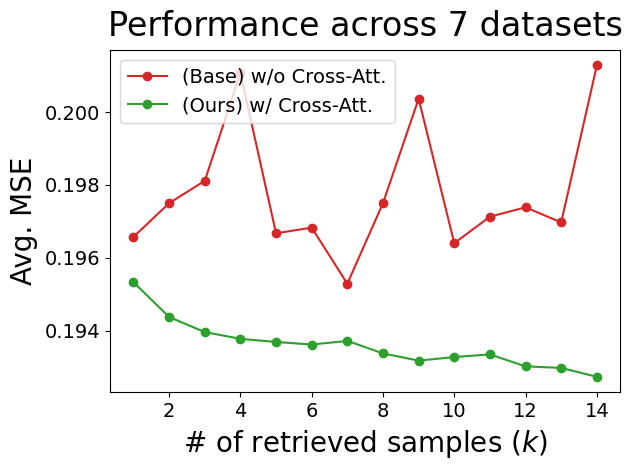

In [50]:
from_ = 0
to_ = 14
plt.plot(range(from_ + 1, to_ +1),filtered_base['Avg'][from_:to_],linestyle='solid',color="tab:red",marker='o',label='(Base) w/o Cross-Att.')
plt.plot(range(from_ + 1, to_ +1),filtered_ours['Avg'][from_:to_],linestyle='solid',color="tab:green",marker='o',label='(Ours) w/ Cross-Att.')
plt.title('Performance across 7 datasets',fontsize=24,pad=10)
plt.legend(fontsize=14,loc='upper left')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'# of retrieved samples ($k$)', fontsize=20,labelpad=5)
plt.ylabel(r'Avg. MSE', fontsize=20,labelpad=5)
# ax[0,0].plot(df1['X'],df1['Y'],color='blue',linestyle='solid',marker='o')
# ax[0,1].plot(df1['X'],df1['Y'],color='blue',linestyle='dotted',marker='o')
# ax[1,0].plot(df1['X'],df1['Y'],color='blue',linestyle='dashed',marker='o')
# ax[1,1].plot(df1['X'],df1['Y'],color='blue',linestyle='dashdot',marker='o')
########################################################################
# plt.tight_layout()
# plt.show()
########################################################################
plt.tight_layout()
SAVE_PATH = '/home/seunghan.lee/workspace/experiments/figures'
fn = "01.motivation_K.pdf"
fn = os.path.join(SAVE_PATH,fn)
plt.savefig(fn, bbox_inches="tight")
plt.show()
